In [1]:
from selenium import webdriver
from selenium.webdriver.support.wait import WebDriverWait
from selenium.webdriver.support import expected_conditions
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.support.ui import Select

import pandas as pd
import pickle
import os
import sys
import warnings
import time

from bs4 import BeautifulSoup
import requests
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36", "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8", "Accept-Language": "en-US,en;q=0.9", "Referer": "https://www.ewg.org/tapwater/", "Connection": "keep-alive"}



from selenium.webdriver.edge.options import Options

edge_options = Options()
#edge_options.add_argument('--headless')
#edge_options.add_argument("--disable-images")  # Disable images
#edge_options.add_argument("--disable-javascript")  # Disable JavaScript
#edge_options.add_argument("--disable-plugins")  # Disable plugins
#edge_options.add_argument("--disable-extensions")  # Disable extensions
#edge_options.add_argument("--blink-settings=imagesEnabled=false")  # Another image disabling flag


# Set a minimal User-Agent (like a text-only browser)
edge_options.add_argument("user-agent=Links (2.25; Linux 2.4.24)")

driver = webdriver.Edge(options=edge_options)
#driver.execute_cdp_cmd("Network.setBlockedURLs", {"urls": ["*.jpg", "*.png", "*.gif","*.svg"]})
#driver.execute_cdp_cmd("Network.enable", {})


driver.maximize_window()

driver.execute_script("document.body.style.zoom='67%'")


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
import matplotlib.pyplot as plt


pd.set_option('display.float_format', '{:,.0f}'.format)

# Scraing

In [3]:
start_url='https://www.transfermarkt.com/statistik/saisontransfers'

driver.get(start_url)

In [ ]:
htmls=[]

for season in range(1870, 2026):
    if season!=2002:
        continue
    htmls=[]
    url=f'https://www.transfermarkt.com/transfers/saisontransfers/statistik/top/plus/0/galerie/0?saison_id={season}&transferfenster=alle&land_id=&ausrichtung=&spielerposition_id=&altersklasse=&leihe=&art='
    driver.get(url)
    WebDriverWait(driver,100).until(expected_conditions.presence_of_element_located((By.CSS_SELECTOR,'body')))
    
    while True:
        try:
            htmls.append(driver.page_source)
            next_page=driver.find_element(By.CSS_SELECTOR,'li.x x')
            parent=next_page.find_element(By.XPATH,'..')
            if 'disabled' in parent.get_attribute('class'): break
            driver.execute_script('arguments[0].click()',next_page)
            WebDriverWait(driver,100).until(expected_conditions.staleness_of(next_page))
            time.sleep(1)
        except:
            break

    pickle.dump(htmls,open(os.path.join('data',f'htmls_{season}.pickle'),'wb'))
    print(season,end='\r')

In [3]:
driver.quit()

data_path=r'D:\Python\Transfermarkt\data'

In [ ]:
all_rows=[]

files=os.listdir(data_path)
for i, file in enumerate(files, start=1):
    season=file.split('_')[-1].split('.')[0]

    htmls=pickle.load(open(os.path.join(data_path, file),'rb'))
    
    for html in htmls:
        soup=BeautifulSoup(html, 'html.parser')
        rows=[i.get_text(separator='|', strip=True).split('|') for i in soup.select('table.x tr.x, table.x tr.x')]
        for row in rows:
            row.append(season)
            
        all_rows.extend(rows)
        
    print(f'{i}/{len(files)}',end='\r')

pickle.dump(all_rows,open(os.path.join('data','all_rows.pickle'),'wb'))

# Cleaning

In [4]:
all_rows=pickle.load(open(os.path.join('data','all_rows.pickle'),'rb'))
len(all_rows)

60681

In [5]:
df=pd.DataFrame(all_rows)
df.columns=['Index', 'Footballer', 'Position', 'Age', 'Market Value', 'Joined Club', 'Joined League', 'Fee', 'Season','None']

df=df.drop(columns='Index')
df=df.reset_index(drop=True)

In [6]:
indexes=df[df['Fee'].str.contains('Loan')].index

In [7]:
for index in indexes:
    df.loc[index, 'Fee']=df.loc[index, 'Season']
    df.loc[index, 'Season']=df.loc[index, 'None']
    df.loc[index, 'Loan']='Yes'

In [8]:
df['Loan']=df['Loan'].fillna('No')

In [9]:
df=df.drop(columns='None')

In [10]:
df['Fee']=df['Fee'].str.replace('free transfer','0')

In [11]:
df=df[(df['Fee'].str.contains('€', na=False)) | (df['Fee'] == '0')]
df=df.reset_index(drop=True)

In [12]:
df=df[df['Season']>='1949']

In [13]:
df

,Footballer,Position,Age,Market Value,Joined Club,Joined League,Fee,Season,Loan
836,Faas Wilkes,Centre-Forward,25,-,Inter,Serie A,€32k,1949,No
837,George Stobbart,Second Striker,28,-,Luton,First Division,€15k,1949,No
838,Jimmy McIlroy,Attacking Midfield,18,-,Burnley,First Division (- 91/92),€8k,1949,No
839,Willie Cunningham,Right-Back,24,-,Preston,First Division,€7k,1949,No
840,Juan Aretio,Midfielder,26,-,Barcelona,LaLiga,€3k,1949,No
...,...,...,...,...,...,...,...,...,...
48962,Luis Corredor,Goalkeeper,28,€275k,Zamora FC,Liga FUTVE Apertura,0,2026,No
48963,Stefano Olaya,Left Winger,23,€275k,Alianza Lima II,Liga 3,0,2026,No
48964,Fabricio Amato,Defensive Midfield,22,€200k,Zalaegerszeg,Hungary,€250k,2026,No
48965,Andreas Athanasiou,Attacking Midfield,22,€250k,Apol. Limassol,Cyprus,€50k,2026,No


In [14]:
df['Age']=df['Age'].apply(pd.to_numeric,errors='coerce')

In [15]:
df['Market Value']=df['Market Value'].apply(lambda x:
                         float(str(x).replace('€','').replace('k',''))*1000 if 'k' in str(x) else
                         float(str(x).replace('€','').replace('m',''))*1000000 if 'm' in str(x) else
                         float(str(x).replace('€','')) if x!='-' else None
                        )


df['Fee']=df['Fee'].apply(lambda x:
                         float(str(x).replace('€','').replace('k',''))*1000 if 'k' in str(x) else
                         float(str(x).replace('€','').replace('m',''))*1000000 if 'm' in str(x) else
                         float(str(x).replace('€','')) if x!='-' else None
                        )

In [16]:
cpi= {
    1949: 19.7, 1950: 18.4, 1951: 19.8, 1952: 20.2, 1953: 19.9,
    1954: 20.0, 1955: 20.3, 1956: 20.9, 1957: 21.3, 1958: 21.8,
    1959: 21.9, 1960: 22.3, 1961: 22.9, 1962: 23.5, 1963: 24.2,
    1964: 24.8, 1965: 25.6, 1966: 26.4, 1967: 26.9, 1968: 27.3,
    1969: 27.8, 1970: 28.8, 1971: 30.3, 1972: 31.9, 1973: 34.2,
    1974: 36.6, 1975: 38.8, 1976: 40.4, 1977: 41.9, 1978: 43.0,
    1979: 44.8, 1980: 47.2, 1981: 50.2, 1982: 52.8, 1983: 54.5,
    1984: 55.9, 1985: 57.0, 1986: 56.9, 1987: 57.0, 1988: 57.7,
    1989: 59.3, 1990: 60.8, 1991: 63.0, 1992: 65.5, 1993: 67.9,
    1994: 69.7, 1995: 71.0, 1996: 72.0, 1997: 73.4, 1998: 74.0,
    1999: 74.5, 2000: 75.5, 2001: 77.0, 2002: 78.1, 2003: 78.9,
    2004: 80.2, 2005: 81.5, 2006: 82.8, 2007: 84.7, 2008: 86.9,
    2009: 87.2, 2010: 88.1, 2011: 90.0, 2012: 91.7, 2013: 93.1,
    2014: 94.0, 2015: 94.5, 2016: 95.0, 2017: 96.4, 2018: 98.1,
    2019: 99.5, 2020: 100.0, 2021: 103.1, 2022: 110.2, 2023: 116.7,
    2024: 119.3, 2025: 121.9, 2026: 124.5,
}

In [17]:
df['Season']=df['Season'].astype(int)

In [18]:
df['CPI']=df['Season'].map(cpi)

In [19]:
df['Fee (CPI Adjusted)']=df['Fee']*(124.5/df['CPI']).astype(float)

In [20]:
df=df[df['Fee']!=0]

# EDA

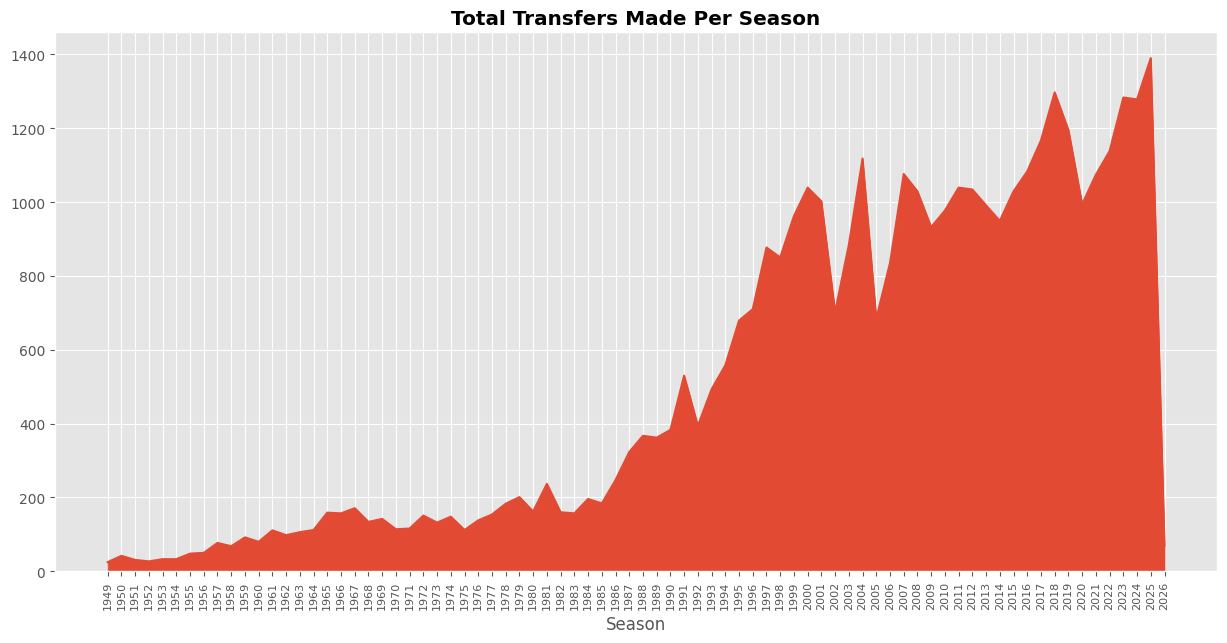

In [21]:
plt.figure(figsize=(15,7))
df.groupby('Season')['Footballer'].count().plot.area()
plt.title('Total Transfers Made Per Season',fontweight='bold')
plt.xticks(df['Season'].unique(), rotation=90, size=8)
plt.show()

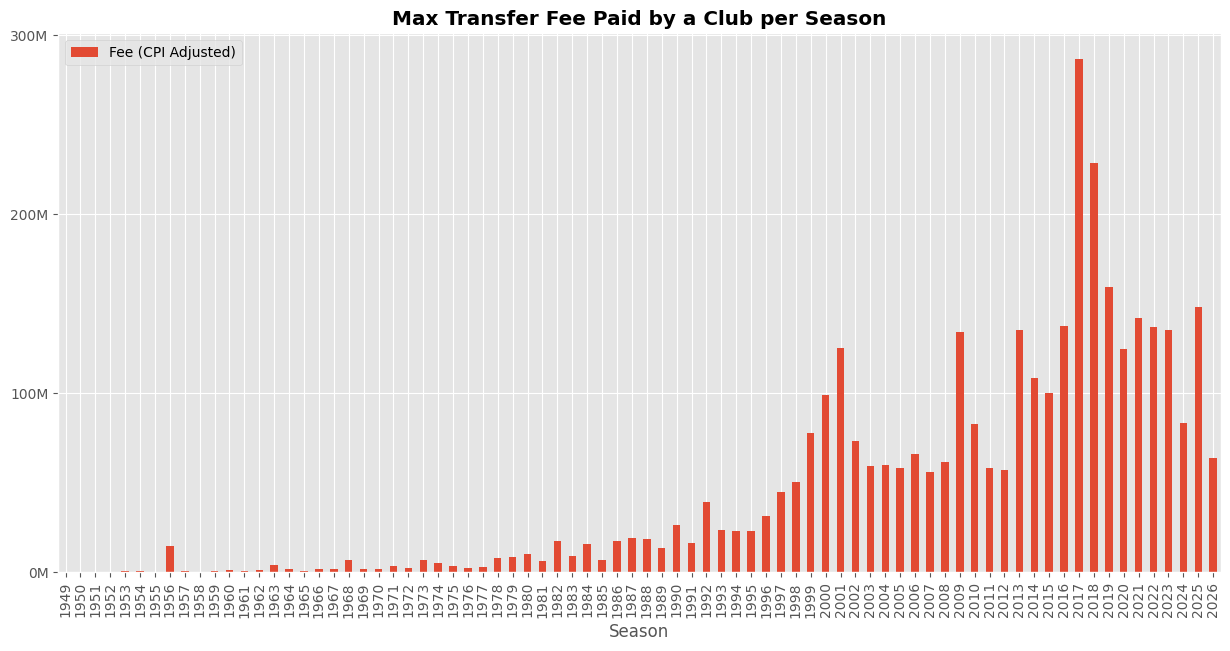

In [22]:
grouped=df.groupby('Season')['Fee (CPI Adjusted)'].max().reset_index()

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

ax = grouped.plot.bar(x='Season', figsize=(15,7))

plt.title('Max Transfer Fee Paid by a Club per Season', fontweight='bold')

ax.yaxis.set_major_locator(mtick.MultipleLocator(100_000_000))
ax.yaxis.set_major_formatter(lambda x, pos: f'{x/1e6:.0f}M')

plt.show()

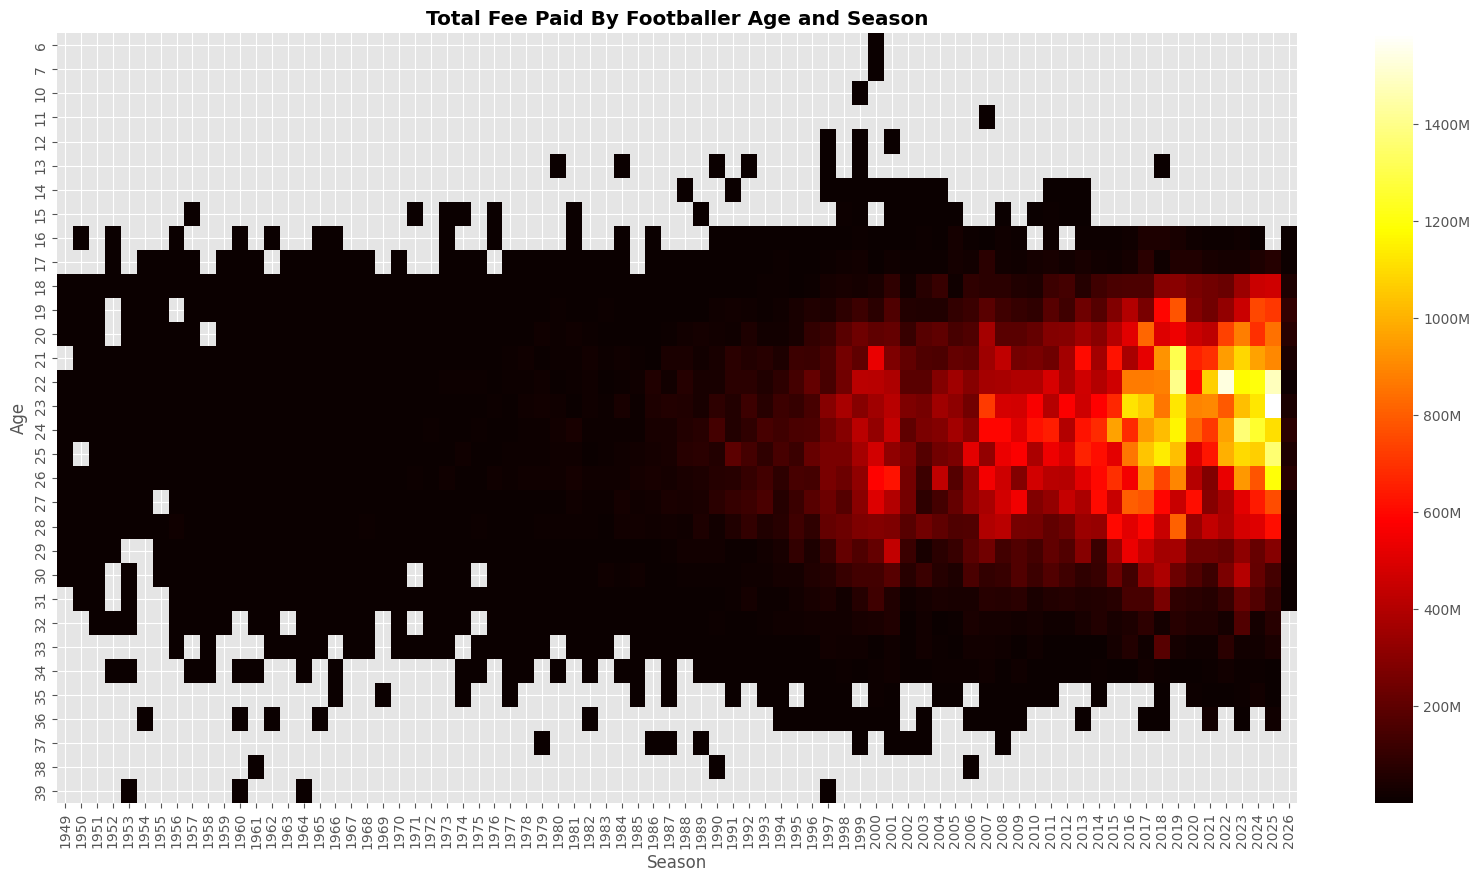

In [24]:
filtered=df[df['Loan']=='No']

grouped=filtered.groupby(['Season', 'Age']).agg({'Fee (CPI Adjusted)':'sum', 'Footballer':'count'}).reset_index()
grouped=grouped.sort_values('Fee (CPI Adjusted)', ascending=False)
grouped['Age']=grouped['Age'].astype(int)

pivot=grouped.pivot_table(columns='Season', index='Age', values='Fee (CPI Adjusted)', aggfunc='sum')


import matplotlib.ticker as mtick

plt.figure(figsize=(20,10))
ax = sns.heatmap(pivot, cmap='hot')

plt.title('Total Fee Paid By Footballer Age and Season', fontweight='bold')

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))

plt.show()

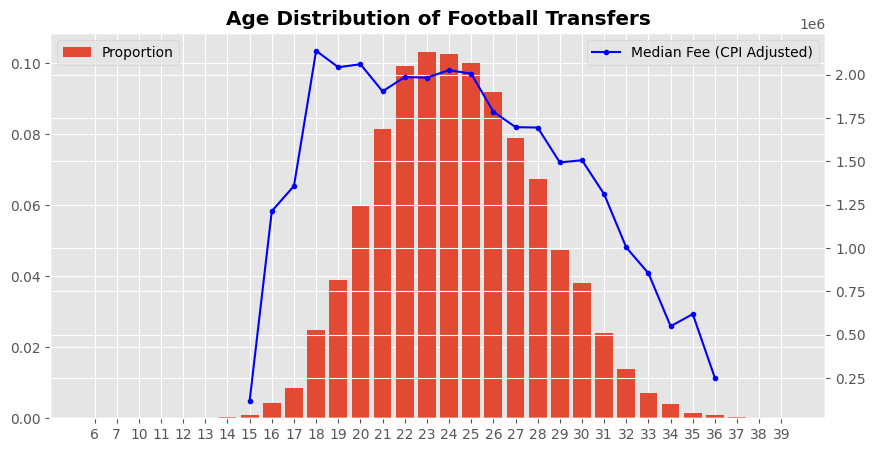

In [82]:
grouped_1=df['Age'].value_counts(normalize=True).sort_index()
grouped_2=df.groupby('Age').filter(lambda x:x['Footballer'].count()>30).groupby('Age')['Fee (CPI Adjusted)'].median()
grouped = grouped.sort_values('Age').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10,5))
ax2 = ax.twinx()

x = range(len(grouped))

ax.bar(x, grouped['proportion'],label='Proportion')
ax2.plot(x, grouped['Fee (CPI Adjusted)'], color='Blue', marker='.', label='Median Fee (CPI Adjusted)')

ax.set_xticks(x)
ax.set_xticklabels(grouped['Age'].astype(int))

plt.title('Age Distribution of Football Transfers', fontweight='bold')

ax.legend(loc='upper left')
ax2.legend()

plt.show()